In [33]:
# Install (if needed)
!pip install scikit-learn

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [34]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize [0,1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(x_train.shape, y_train.shape)

(50000, 32, 32, 3) (50000, 10)


In [36]:
def build_model():
    model = tf.keras.Sequential()

    # Conv 1
    model.add(tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
    model.add(tf.keras.layers.MaxPooling2D((2,2)))   # 32 → 16

    # Conv 2
    model.add(tf.keras.layers.Conv2D(64, (5,5), padding='same', activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D((2,2)))   # 16 → 8

    # Conv 3
    model.add(tf.keras.layers.Conv2D(128, (7,7), padding='same', activation='relu'))  # SAFE now

    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [37]:
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

# Save model
model.save("cifar10_model.h5")

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3295 - loss: 1.7160 - val_accuracy: 0.5919 - val_loss: 1.3121
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3431 - loss: 1.6717 - val_accuracy: 0.5413 - val_loss: 1.3122
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3534 - loss: 1.6406 - val_accuracy: 0.5989 - val_loss: 1.3128
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3649 - loss: 1.6270 - val_accuracy: 0.5811 - val_loss: 1.3163
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3706 - loss: 1.6032 - val_accuracy: 0.5977 - val_loss: 1.2956
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3842 - loss: 1.5885 - val_accuracy: 0.6431 - val_loss: 1.2153
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.3885 - loss: 1.5810 - val_accuracy: 0.6503 - val_loss: 1.1971
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.3956 - loss: 1.5617 - val_accur

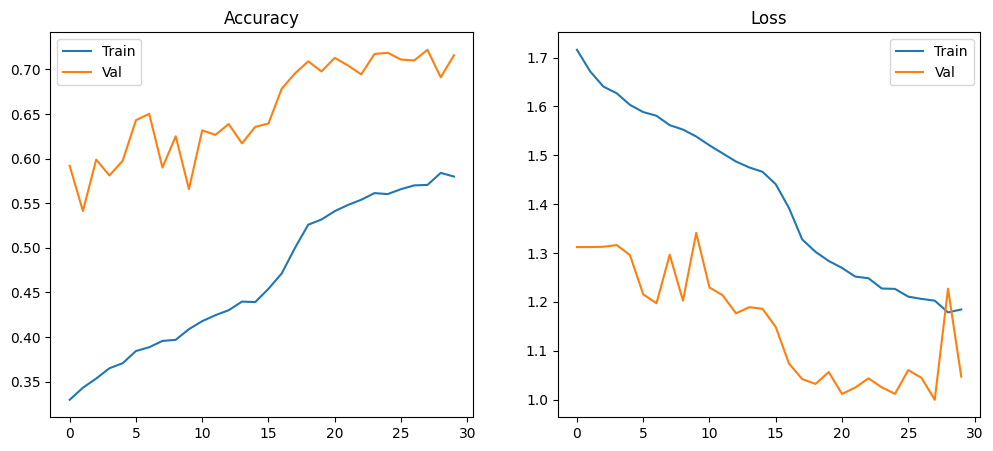

In [38]:
def plot_history(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title("Loss")
    plt.legend()

    plt.show()

plot_history(history)

In [39]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

def fgsm_attack(model, images, labels, epsilon):
    images = tf.convert_to_tensor(images)

    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images)
        loss = loss_object(labels, predictions)

    gradient = tape.gradient(loss, images)
    signed_grad = tf.sign(gradient)

    adv_images = images + epsilon * signed_grad
    adv_images = tf.clip_by_value(adv_images, 0, 1)

    return adv_images

In [40]:
def bim_attack(model, images, labels, epsilon=0.03, alpha=0.005, iterations=10):
    adv_images = images

    for i in range(iterations):
        adv_images = fgsm_attack(model, adv_images, labels, alpha)

        # Project into epsilon ball
        adv_images = tf.clip_by_value(adv_images, images - epsilon, images + epsilon)
        adv_images = tf.clip_by_value(adv_images, 0, 1)

    return adv_images

In [41]:
def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.005, iterations=20):
    adv_images = images + tf.random.uniform(images.shape, -epsilon, epsilon)
    adv_images = tf.clip_by_value(adv_images, 0, 1)

    for i in range(iterations):
        adv_images = fgsm_attack(model, adv_images, labels, alpha)

        adv_images = tf.clip_by_value(adv_images, images - epsilon, images + epsilon)
        adv_images = tf.clip_by_value(adv_images, 0, 1)

    return adv_images

In [42]:
def evaluate(model, x, y, name=""):
    loss, acc = model.evaluate(x, y, verbose=0)
    print(f"\n{name} Accuracy: {acc:.4f}, Loss: {loss:.4f}")

    y_pred = model.predict(x)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y, axis=1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_classes))

    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return acc


Clean Accuracy: 0.7096, Loss: 1.0818
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.78      0.76      1000
           1       0.94      0.76      0.84      1000
           2       0.49      0.75      0.59      1000
           3       0.48      0.47      0.47      1000
           4       0.74      0.46      0.57      1000
           5       0.65      0.57      0.61      1000
           6       0.77      0.87      0.82      1000
           7       0.90      0.71      0.80      1000
           8       0.77      0.89      0.83      1000
           9       0.79      0.84      0.81      1000

    accuracy                           0.71     10000
   macro avg       0.73      0.71      0.71     10000
weighted avg       0.73      0.71      0.71     10000



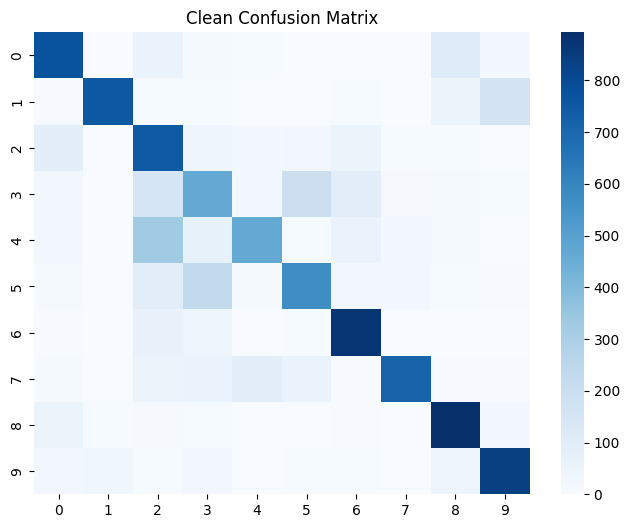


FGSM eps=0.01 Accuracy: 0.2422, Loss: 3.8282
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.37      0.32      1000
           1       0.51      0.26      0.34      1000
           2       0.12      0.23      0.16      1000
           3       0.07      0.06      0.06      1000
           4       0.05      0.02      0.03      1000
           5       0.15      0.10      0.12      1000
           6       0.26      0.36      0.30      1000
           7       0.43      0.25      0.32      1000
           8       0.34      0.42      0.38      1000
           9       0.33      0.35      0.34      1000

    accuracy                           0.24     10000
   macro avg       0.25      0.24      0.24     10000
weighted avg       0.25      0.24      0.24     10000



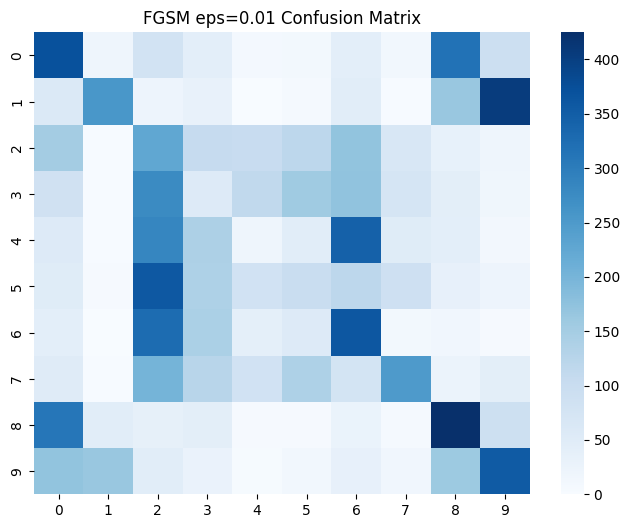


FGSM eps=0.03 Accuracy: 0.0367, Loss: 8.1622
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.09      0.07      1000
           1       0.01      0.00      0.01      1000
           2       0.04      0.08      0.05      1000
           3       0.03      0.03      0.03      1000
           4       0.00      0.00      0.00      1000
           5       0.01      0.01      0.01      1000
           6       0.02      0.04      0.03      1000
           7       0.03      0.01      0.02      1000
           8       0.06      0.06      0.06      1000
           9       0.05      0.04      0.05      1000

    accuracy                           0.04     10000
   macro avg       0.03      0.04      0.03     10000
weighted avg       0.03      0.04      0.03     10000



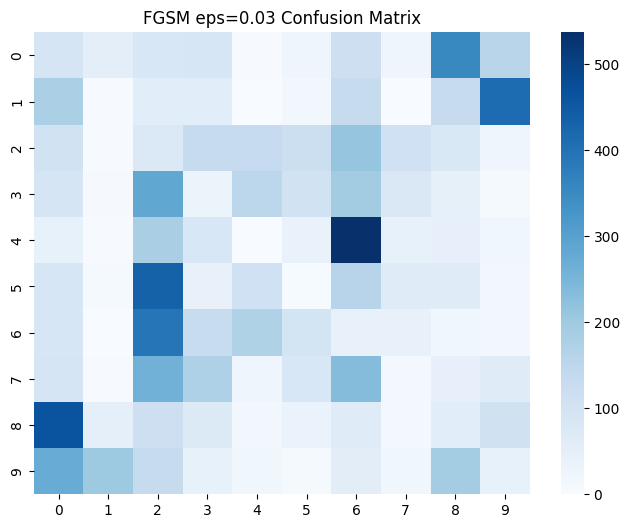


FGSM eps=0.05 Accuracy: 0.0198, Loss: 11.1181
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.03      0.04      0.03      1000
           1       0.00      0.00      0.00      1000
           2       0.03      0.07      0.04      1000
           3       0.05      0.04      0.04      1000
           4       0.00      0.00      0.00      1000
           5       0.01      0.00      0.01      1000
           6       0.01      0.04      0.02      1000
           7       0.00      0.00      0.00      1000
           8       0.01      0.01      0.01      1000
           9       0.01      0.01      0.01      1000

    accuracy                           0.02     10000
   macro avg       0.02      0.02      0.02     10000
weighted avg       0.02      0.02      0.02     10000



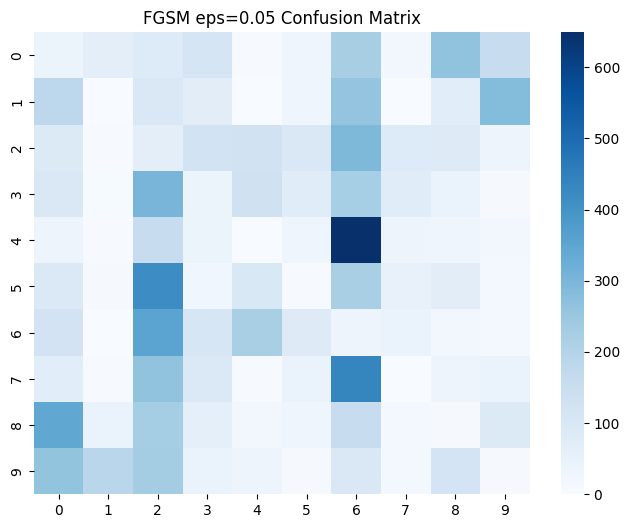


FGSM eps=0.1 Accuracy: 0.0272, Loss: 14.4437
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.01      0.01      0.01      1000
           1       0.00      0.00      0.00      1000
           2       0.04      0.09      0.05      1000
           3       0.07      0.03      0.05      1000
           4       0.00      0.00      0.00      1000
           5       0.01      0.00      0.01      1000
           6       0.03      0.13      0.05      1000
           7       0.00      0.00      0.00      1000
           8       0.01      0.00      0.00      1000
           9       0.01      0.01      0.01      1000

    accuracy                           0.03     10000
   macro avg       0.02      0.03      0.02     10000
weighted avg       0.02      0.03      0.02     10000



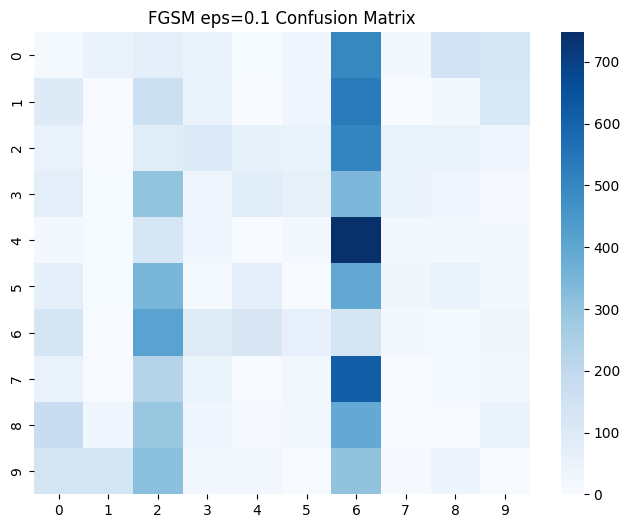


BIM Accuracy: 0.0058, Loss: 27.3679
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.02      0.03      0.02      1000
           1       0.00      0.00      0.00      1000
           2       0.00      0.00      0.00      1000
           3       0.00      0.00      0.00      1000
           4       0.00      0.00      0.00      1000
           5       0.00      0.00      0.00      1000
           6       0.00      0.01      0.00      1000
           7       0.00      0.00      0.00      1000
           8       0.03      0.02      0.03      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.01     10000
   macro avg       0.01      0.01      0.01     10000
weighted avg       0.01      0.01      0.01     10000



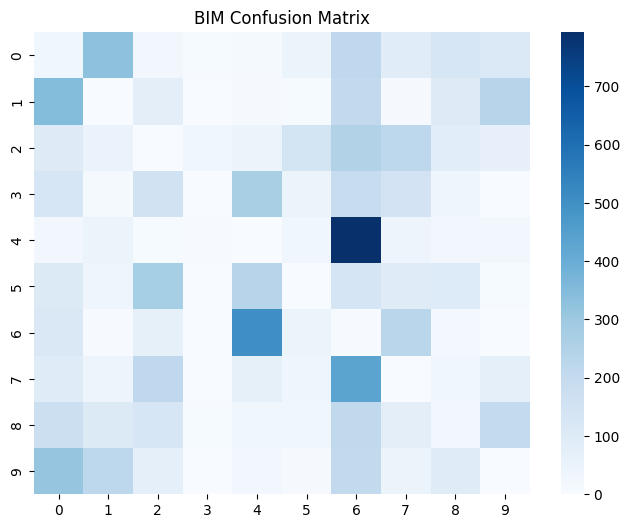


PGD Accuracy: 0.0044, Loss: 35.5933
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.02      0.03      0.02      1000
           1       0.00      0.00      0.00      1000
           2       0.00      0.00      0.00      1000
           3       0.00      0.00      0.00      1000
           4       0.00      0.00      0.00      1000
           5       0.00      0.00      0.00      1000
           6       0.00      0.01      0.00      1000
           7       0.00      0.00      0.00      1000
           8       0.02      0.01      0.01      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.00     10000
   macro avg       0.00      0.00      0.00     10000
weighted avg       0.00      0.00      0.00     10000



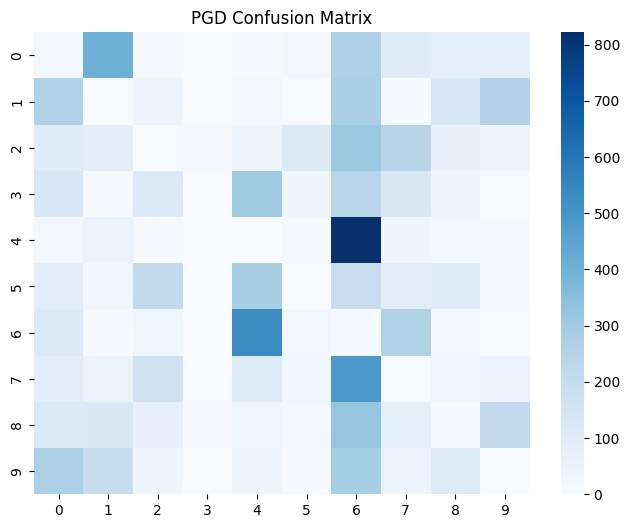

In [43]:
results = []

# Clean
clean_acc = evaluate(model, x_test, y_test, "Clean")
results.append(("Clean", "-", clean_acc))

# FGSM
epsilons = [0.01, 0.03, 0.05, 0.1]

for eps in epsilons:
    adv = fgsm_attack(model, x_test, y_test, eps)
    acc = evaluate(model, adv, y_test, f"FGSM eps={eps}")
    results.append(("FGSM", eps, acc))

# BIM
bim_adv = bim_attack(model, x_test, y_test)
bim_acc = evaluate(model, bim_adv, y_test, "BIM")
results.append(("BIM", 0.03, bim_acc))

# PGD
pgd_adv = pgd_attack(model, x_test, y_test)
pgd_acc = evaluate(model, pgd_adv, y_test, "PGD")
results.append(("PGD", 0.03, pgd_acc))

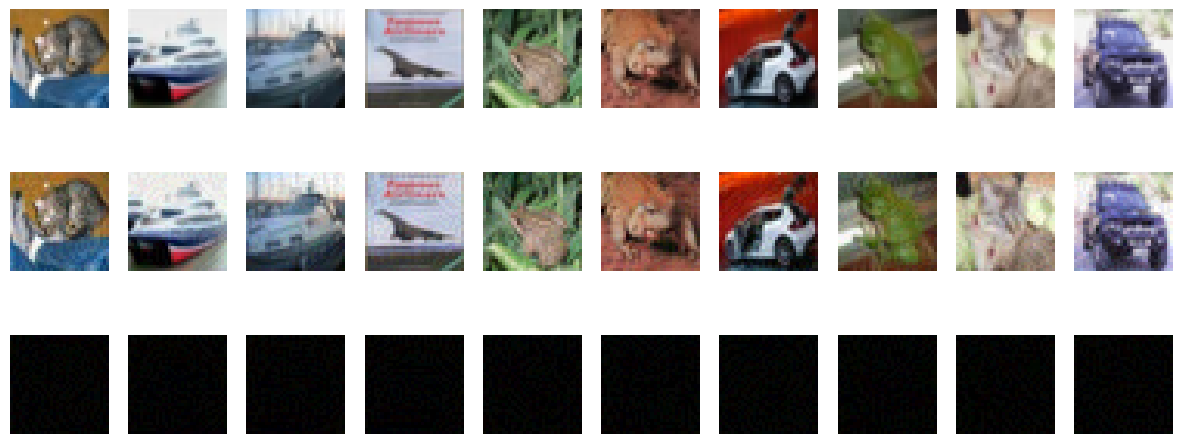

In [44]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

def visualize_examples(model, x, y, adv):
    plt.figure(figsize=(15,6))

    for i in range(10):
        plt.subplot(3,10,i+1)
        plt.imshow(x[i])
        plt.axis('off')

        plt.subplot(3,10,i+11)
        plt.imshow(adv[i])
        plt.axis('off')

        plt.subplot(3,10,i+21)
        plt.imshow(adv[i] - x[i])
        plt.axis('off')

    plt.show()

# Example using PGD
visualize_examples(model, x_test, y_test, pgd_adv)

In [45]:
print("\nAttack | Epsilon | Accuracy")
for r in results:
    print(f"{r[0]} | {r[1]} | {r[2]:.4f}")


Attack | Epsilon | Accuracy
Clean | - | 0.7096
FGSM | 0.01 | 0.2422
FGSM | 0.03 | 0.0367
FGSM | 0.05 | 0.0198
FGSM | 0.1 | 0.0272
BIM | 0.03 | 0.0058
PGD | 0.03 | 0.0044


 Strongest Attack
PGD is strongest
Because it performs multiple optimized steps + projection
 Effect of Epsilon
Higher epsilon → larger perturbation → lower accuracy
Too high → visible noise
 Why PGD > FGSM
FGSM = single step (weak)
BIM = iterative (stronger)
PGD = iterative + random start (strongest)
 Robustness Insight
CNN is highly vulnerable to small perturbations
Need defenses:
Adversarial training
Regularization
Defensive distillation